# Pràctica 2: Aprenentatge no supervisat

## Imports

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import math
from sklearn.preprocessing import StandardScaler
# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Autoencoders
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

#SOM
from minisom import MiniSom

# Metrics / comparison with real classes
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix

# Plots
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from collections import Counter
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

2.12.0+cu130
CUDA available: False


## 1. Lectura de les dades.

In [2]:
# dades sintètiques
synthetic_original = pd.read_csv("A2-synthetic.txt", sep=",")

#dades reals
real_original = pd.read_csv("A2-real.txt", sep=";")

In [3]:
#print(synthetic_original.head())
print(synthetic_original.shape)

#print(real_original.head())
print(real_original.shape)

(360, 5)
(333, 7)


## 2. Pre-processament de les dades

In [4]:
synthetic = synthetic_original.copy()
real = real_original.copy()

Separem les variables que s’utilitzaran com a entrada de les variables auxiliars. Les etiquetes de classe no s’han d’utilitzar durant l’entrenament dels models, sinó només per visualitzar i comparar els resultats obtinguts. En el cas del dataset real, la variable Location tampoc es fa servir per entrenar, però es conserva per a la interpretació posterior dels gràfics.

In [5]:
# Synthetic
X_syn = synthetic.drop(columns=["class"])
y_syn = synthetic["class"]

# Real
X_real = real.drop(columns=["Class", "Location"])
y_real = real["Class"]
location_real = real["Location"]

In [6]:
display(y_syn.value_counts())
display(y_real.value_counts())
display(location_real.value_counts())

class
2    100
6    100
1     63
4     40
5     36
3     21
Name: count, dtype: int64

Class
C1    146
C2    119
C3     68
Name: count, dtype: int64

Location
L2    163
L3    123
L1     47
Name: count, dtype: int64

Hem comprovat la distribució de les classes en els dos datasets i de la variable Location en el dataset real. Observem que les dades no estan perfectament balancejades, ja que algunes classes tenen molts més patrons que d’altres. Això és important per interpretar els gràfics posteriorment, ja que els grups més grans poden dominar visualment els resultats, mentre que els grups més petits poden ser més difícils d’identificar.

In [7]:
scaler_syn = StandardScaler()
X_syn_scaled = scaler_syn.fit_transform(X_syn)

scaler_real = StandardScaler()
X_real_scaled = scaler_real.fit_transform(X_real)

Per finalitzar el preprocessament, estandarditzem les variables d’entrada. Aquest pas és important perquè molts dels mètodes utilitzats depenen de distàncies, variàncies o processos d’optimització, i per tant variables amb escales més grans podrien tenir un pes excessiu. Guardarem les dades ja escalades tant en format DataFrame, per conservar els noms de les variables i facilitar la visualització, com en format array, que resulta més pràctic per aplicar alguns algoritmes.

In [8]:
# Keep scaled data as DataFrame
X_syn_scaled_df = pd.DataFrame(
    X_syn_scaled,
    columns=X_syn.columns,
    index=X_syn.index
)

X_real_scaled_df = pd.DataFrame(
    X_real_scaled,
    columns=X_real.columns,
    index=X_real.index
)

# Also keep NumPy arrays for algorithms: PCA, t-SNE, k-means, AHC, Autoencoder, SOM.
X_syn_scaled_np = X_syn_scaled_df.values
X_real_scaled_np = X_real_scaled_df.values

# Display first rows
display(X_syn_scaled_df.head())
display(X_real_scaled_df.head())

,x1,x2,x3,x4
0,-0.165933,-2.165686,-1.125643,-0.218701
1,-0.075211,1.121416,-0.169405,-0.207301
2,0.403832,-0.219275,0.559468,-0.413849
3,-0.194014,-0.547981,-1.391632,-0.806953
4,-0.248522,-0.225249,0.663554,-0.999257


,BL,BD,FL,BM,S
0,-1.738463,0.475587,-0.998018,-1.625681,1.009050
1,-0.950982,1.441880,-0.783651,-0.319720,-0.991031
2,0.202768,-1.355285,0.431094,1.048429,1.009050
3,-1.720150,2.001313,-0.212006,0.239977,-0.991031
4,-0.621339,0.933305,-0.140551,-0.257532,-0.991031


## 3. Aplicar sis tècniques d’aprenentatge no supervisat:


### PCA: 

La idea del PCA és reduir les dades originals a només dues components principals, conservant les direccions on les dades tenen més variància. Això permet representar dades de més dimensions en un gràfic 2D, perdent la mínima informació possible. En aquest cas, s’utilitza per visualitzar si les classes formen grups diferenciats en l’espai reduït.

In [9]:
def apply_pca(X_scaled, y, dataset_name):
    
    #mirem quantes variables té el dataset per aplicar un PCA amb tantes components com variables
    n_components = X_scaled.shape[1]
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled) #matriu amb coordenades de cada pt en l'espai PCA
    print(X_pca.shape)
    
    # Seleccionem totes les files i només les dues primeres columnes de la projecció PCA
    # corresponents a les dues primeres components principals: PC1 i PC2.
    pca_df = pd.DataFrame(
        X_pca[:, :2], 
        columns=["PC1", "PC2"],
        index=X_scaled.index if hasattr(X_scaled, "index") else None
        #conservem index si es un df, si es un array none
    )
    
    #afegim la classe real
    pca_df["class"] = y.values

    #guardem varinaça
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    #Projecció PCA
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="class",
        palette="tab10",
        s=60
    )

    plt.title(f"Projecció PCA  - {dataset_name}")
    plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variança)")
    plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variança)")
    plt.legend(title="Classe")
    plt.grid(True)
    plt.show()

    # 2. Scree plot: variança acumulada en funció del nre de components
    plt.figure(figsize=(7, 5))
    plt.plot(
        range(1, n_components + 1),
        cumulative_variance,
        marker="o"
    )

    plt.title(f"Scree plot - {dataset_name}")
    plt.xlabel("Nombre de components principals")
    plt.ylabel("Variança acumulada")
    plt.xticks(range(1, n_components + 1))
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()

    return pca_df, pca

(360, 4)


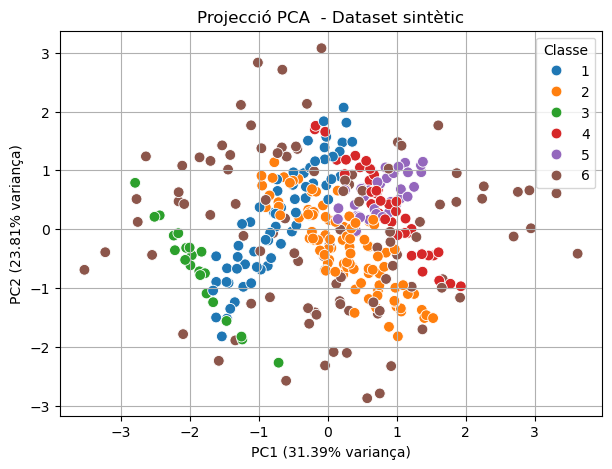

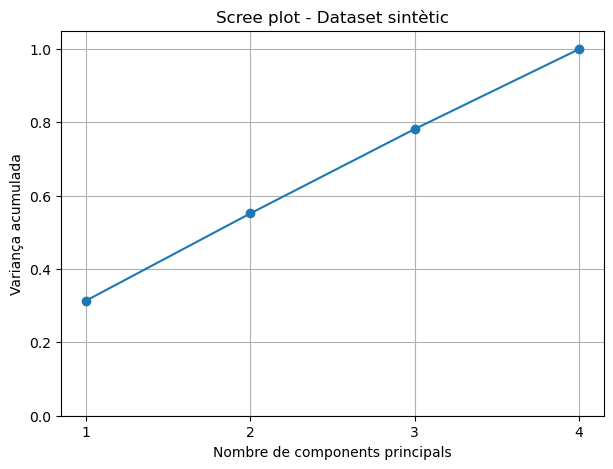

(333, 5)


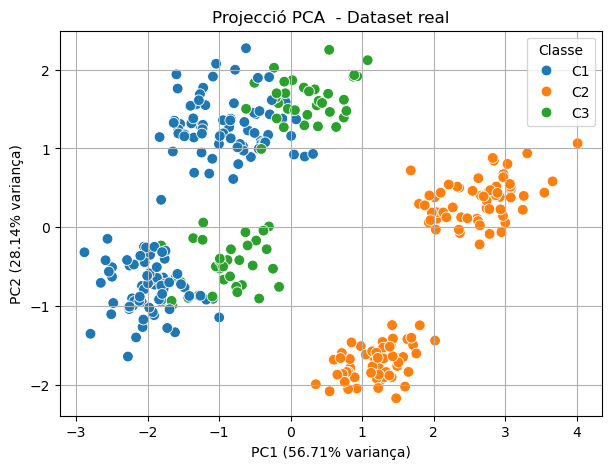

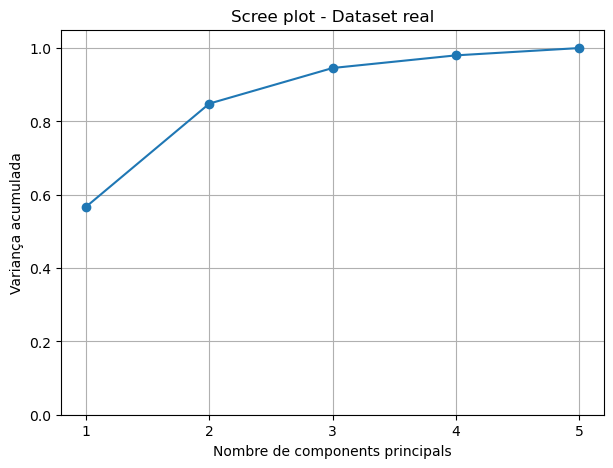

,PC1,PC2,class
0,-1.615413,-0.461632,1
1,0.499510,0.700627,5
2,0.603876,-0.296531,2
3,-0.726266,0.649637,1
4,0.633048,0.427483,4


,PC1,PC2,class
0,-2.653307,-0.704220,C1
1,-1.313026,1.563658,C1
2,1.139419,-1.578386,C2
3,-1.221611,1.771707,C1
4,-0.594826,1.229541,C1


In [10]:
# PCA per dades sintetiques
pca_syn_df, pca_syn = apply_pca(
    X_syn_scaled_df,
    y_syn,
    "Dataset sintètic"
)

# PCA per dades reals
pca_real_df, pca_real = apply_pca(
    X_real_scaled_df,
    y_real,
    "Dataset real"
)

# Show results
display(pca_syn_df.head())
display(pca_real_df.head())

#### Conclusions PCA

En el dataset sintètic, la projecció PCA mostra un solapament important entre les classes. Això és coherent amb el scree plot, ja que les dues primeres components principals només acumulen aproximadament un 60% de la variància total. Per tant, en reduir les dades a dues dimensions es perd una part rellevant de la informació, i és possible que part de la separació entre classes quedi en components posteriors.

En canvi, en el dataset real s’observa una separació més clara entre les classes, especialment per a la classe C2. En aquest cas, les dues primeres components principals acumulen aproximadament un 85% de la variància total, de manera que la representació en dues dimensions conserva gran part de la informació original. Això fa que el PCA sigui més adequat per visualitzar l’estructura del dataset real que la del dataset sintètic.

### t-SNE


El t-SNE (t-distributed Stochastic Neighbor Embedding) és un mètode que es fa servir principalment per visualització i es basa en el fet que els objectes similars en l'espai original han de quedar a prop també en l'espai projectat. Per a això, modela les distàncies entre punts en l'espai original amb distribucions gaussianes, modela les distàncies en l'espai projectat amb una distribució t de Student, i minimitza la divergència KL (Kullback–Leibler) entre totes dues distribucions. A més, el paràmetre perplexity representa aproximadament el nombre efectiu de veïns que l'algorisme té en compte.

In [11]:
def apply_tsne(X_scaled, y, dataset_name, perplexities=[5, 10, 30, 50]):
  #valors perplexity de prova: nombre efectiu de veïns
    
    tsne_results = {} #creem diccionari

    n_samples = X_scaled.shape[0]  #nre de patrons

    perplexities = list(perplexities)

    n_rows = 2
    n_cols = int(np.ceil(len(perplexities) / n_rows))

    # Creem una figura amb dues files de gràfiques perquè no quedin massa petites
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    plot_idx = 0

    for perplexity in perplexities:

        if perplexity >= n_samples:
            print(f"No s'aplica t-SNE amb perplexity={perplexity}, perquè ha de ser menor que n_samples={n_samples}")
        else:
            tsne = TSNE(
                n_components=2, #volem reduir a 2 dimensions
                perplexity=perplexity,
                learning_rate="auto",
                init="pca", # Inicialitzem t-SNE amb PCA perquè el resultat sigui més estable que amb una inicialització aleatòria
                random_state=RANDOM_STATE
            )

            X_tsne = tsne.fit_transform(X_scaled)

            tsne_df = pd.DataFrame(
                X_tsne,
                columns=["tSNE1", "tSNE2"],
                index=X_scaled.index if hasattr(X_scaled, "index") else None
                #conservem index si es un df, si es un array none
            )

            tsne_df["class"] = y.values
            tsne_results[perplexity] = tsne_df
            #guardem dataframe al diccionari amb el valor de perplexity com clau

            ax = axes[plot_idx]

            sns.scatterplot(
                data=tsne_df,
                x="tSNE1",
                y="tSNE2",
                hue="class",
                palette="tab10",
                s=60,
                ax=ax
            )

            ax.set_title(f"Projecció t-SNE - {dataset_name} - perplexity={perplexity}")
            ax.set_xlabel("t-SNE 1")
            ax.set_ylabel("t-SNE 2")
            ax.legend(title="Classe")
            ax.grid(True)

            plot_idx += 1

    # Amaguem els subplots buits si el nombre de valors de perplexity no omple tota la graella
    for j in range(plot_idx, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return tsne_results

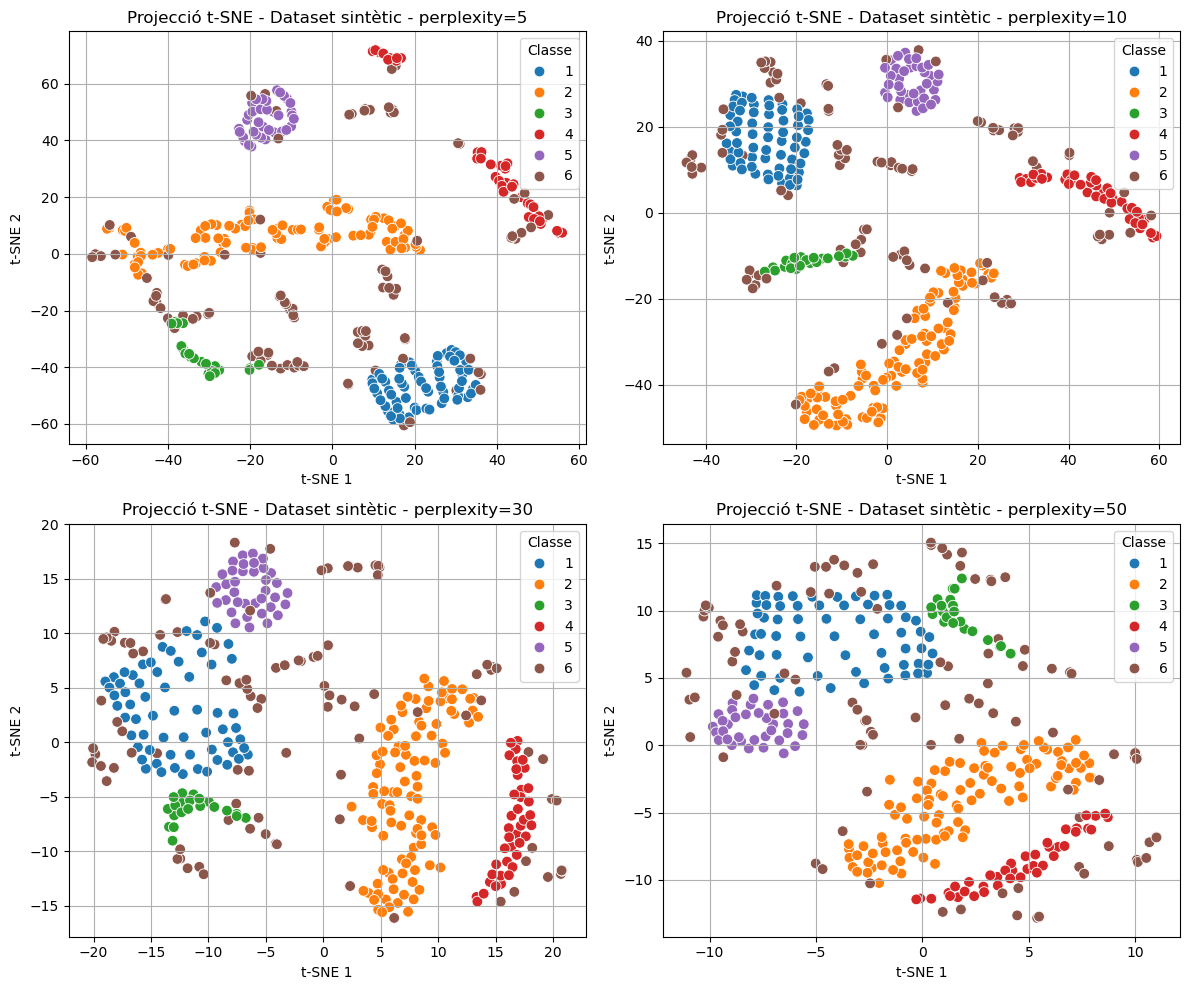

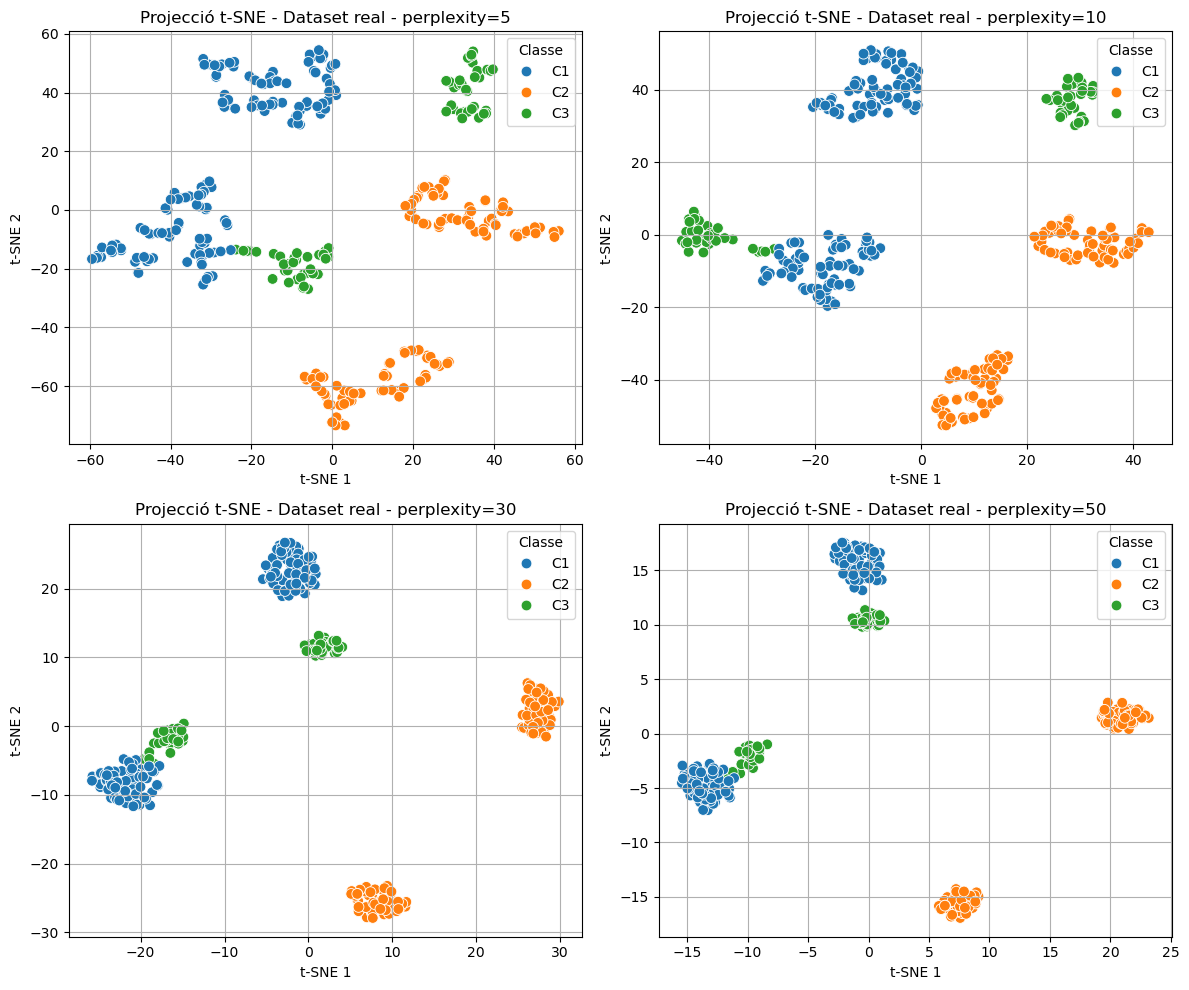

,tSNE1,tSNE2,class
0,-23.529404,-10.444178,C1
1,-4.385883,22.853743,C1
2,9.032087,-27.406357,C2
3,-5.420836,21.394278,C1
4,-1.218725,21.740320,C1


In [12]:
tsne_syn_results = apply_tsne(
    X_syn_scaled_df,
    y_syn,
    "Dataset sintètic",
    perplexities=[5, 10, 30, 50]
)

tsne_real_results = apply_tsne(
    X_real_scaled_df,
    y_real,
    "Dataset real",
    perplexities=[5, 10, 30, 50]
)

tsne_syn_results[30].head()
tsne_real_results[30].head()

#### Conclusions t-SNE

A diferència del PCA, el t-SNE no calcula directament una projecció lineal fixa. Primer col·loca els punts en un espai 2D i, a partir d'aquesta configuració inicial, els va movent de manera iterativa. L'objectiu d'aquest procés és que els punts que eren propers o similars en l'espai original acabin quedant també propers en la representació 2D. Per això, el resultat final pot mostrar agrupacions o separacions entre classes que no serien tan evidents amb una projecció lineal.

En el conjunt de dades sintètic, algunes classes, com ara la 1, 4 i 5, formen grups compactes mentre que altres apareixen més disperses. Concretament, la classe 6 queda repartida per diferents zones de la representació, cosa que indica que els seus patrons poden ser més heterogenis o estar més propers a altres classes en l'espai original. El valor de perplexity afecta bastant: amb valors baixos apareixen grups més petits i separats, mentre que amb valors més alts l'estructura és més global.

En el conjunt de dades real, la separació entre classes és més clara. Les classes C1, C2 i C3 apareixen bastant diferenciades, especialment per valors de perplexity iguals a 30 i 50. Algunes classes es divideixen en més d'un grup, com C1 i C2, fet que pot indicar que dins d'una mateixa classe hi ha subestructures internes o patrons amb característiques diferents.



Cal recordar que els eixos t-SNE 1 i t-SNE 2 no tenen una interpretació directa. L'important és la proximitat relativa entre punts i la formació de grups. Per tant, el t-SNE és útil per visualitzar l'estructura de les dades i detectar possibles agrupacions.-

### K-means

El k-means és un mètode fer clustering, és a dir, per agrupar patrons similars dins d'un mateix grup. 

La idea principal és fixar un nombre de clústers \(k\) i representar cada clúster mitjançant un centroide. Inicialment, aquests centroides es col·loquen en diferents posicions i, de manera iterativa, cada patró s'assigna al centroide més proper. Després, els centroides es recalculen com la mitjana dels punts assignats a cada clúster. Aquest procés es repeteix fins que les assignacions ja no canvien de manera significativa.

En aquesta pràctica s'aplica k-means per a diferents valors de \(k\), i els clústers obtinguts es comparen amb les classes reals. Les classes reals no s'utilitzen per entrenar el model, sinó només per interpretar si els grups trobats per l'algorisme tenen relació amb l'estructura real de les dades.

Per fer aquesta comparació s'utilitzen dues mètriques: l'ARI (Adjusted Rand Index) i l'NMI (Normalized Mutual Information). L'ARI mesura fins a quin punt les assignacions dels clústers coincideixen amb les classes reals, corregint l'efecte de possibles coincidències aleatòries. L'NMI mesura la informació compartida entre els clústers obtinguts i les classes reals. En tots dos casos, valors més alts indiquen una millor correspondència entre els clústers trobats i les classes reals.

In [13]:
def apply_kmeans(X_scaled, pca_df, y_true, dataset_name, k_values):

    results = []
    kmeans_results = {}
    #diccionari on es guardaran les etiquetes de cluster obtingudes per cada valor de k

    k_values = list(k_values)

    n_rows = 2
    n_cols = int(np.ceil(len(k_values) / n_rows))

    # Creem una figura amb dues files de gràfiques perquè no quedin massa petites
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    axes = axes.flatten()

    for i, k in enumerate(k_values):

        kmeans = KMeans(
            n_clusters=k, #Indica quants clústers volem trobar, canvia en cada iteració del bucle.
            random_state=RANDOM_STATE,
            n_init=10 ## Executem k-means 10 vegades amb inicialitzacions diferents i ens quedem amb la millor solució
        )

        #Entrenem k-means i assignem a cada patró el clúster corresponent
        cluster_labels = kmeans.fit_predict(X_scaled)

        kmeans_results[k] = cluster_labels

        #Calculem l'ARI per comparar els clústers obtinguts amb les classes reals
        ari = adjusted_rand_score(y_true, cluster_labels)

        #Avaluem fins a quin punt els clústers trobats per k-means coincideixen amb les classes reals
        nmi = normalized_mutual_info_score(y_true, cluster_labels)

        results.append({
            "k": k,
            "ARI": ari,
            "NMI": nmi,
            "Inertia": kmeans.inertia_   #La inèrcia suma les distàncies quadràtiques dels punts al seu centroide més proper
        })

        plot_df = pca_df[["PC1", "PC2"]].copy()
        plot_df["cluster"] = cluster_labels
        plot_df["real_class"] = y_true.values

        ax = axes[i]

        sns.scatterplot(
            data=plot_df,
            x="PC1",
            y="PC2",
            hue="cluster",
            palette="tab10",
            s=60,
            ax=ax
        )

        ax.set_title(f"Clustering amb k-means - {dataset_name} - k={k}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(title="Clúster")
        ax.grid(True)

    # Amaguem els subplots buits si el nombre de valors de k no omple tota la graella
    for j in range(len(k_values), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)

    return results_df, kmeans_results

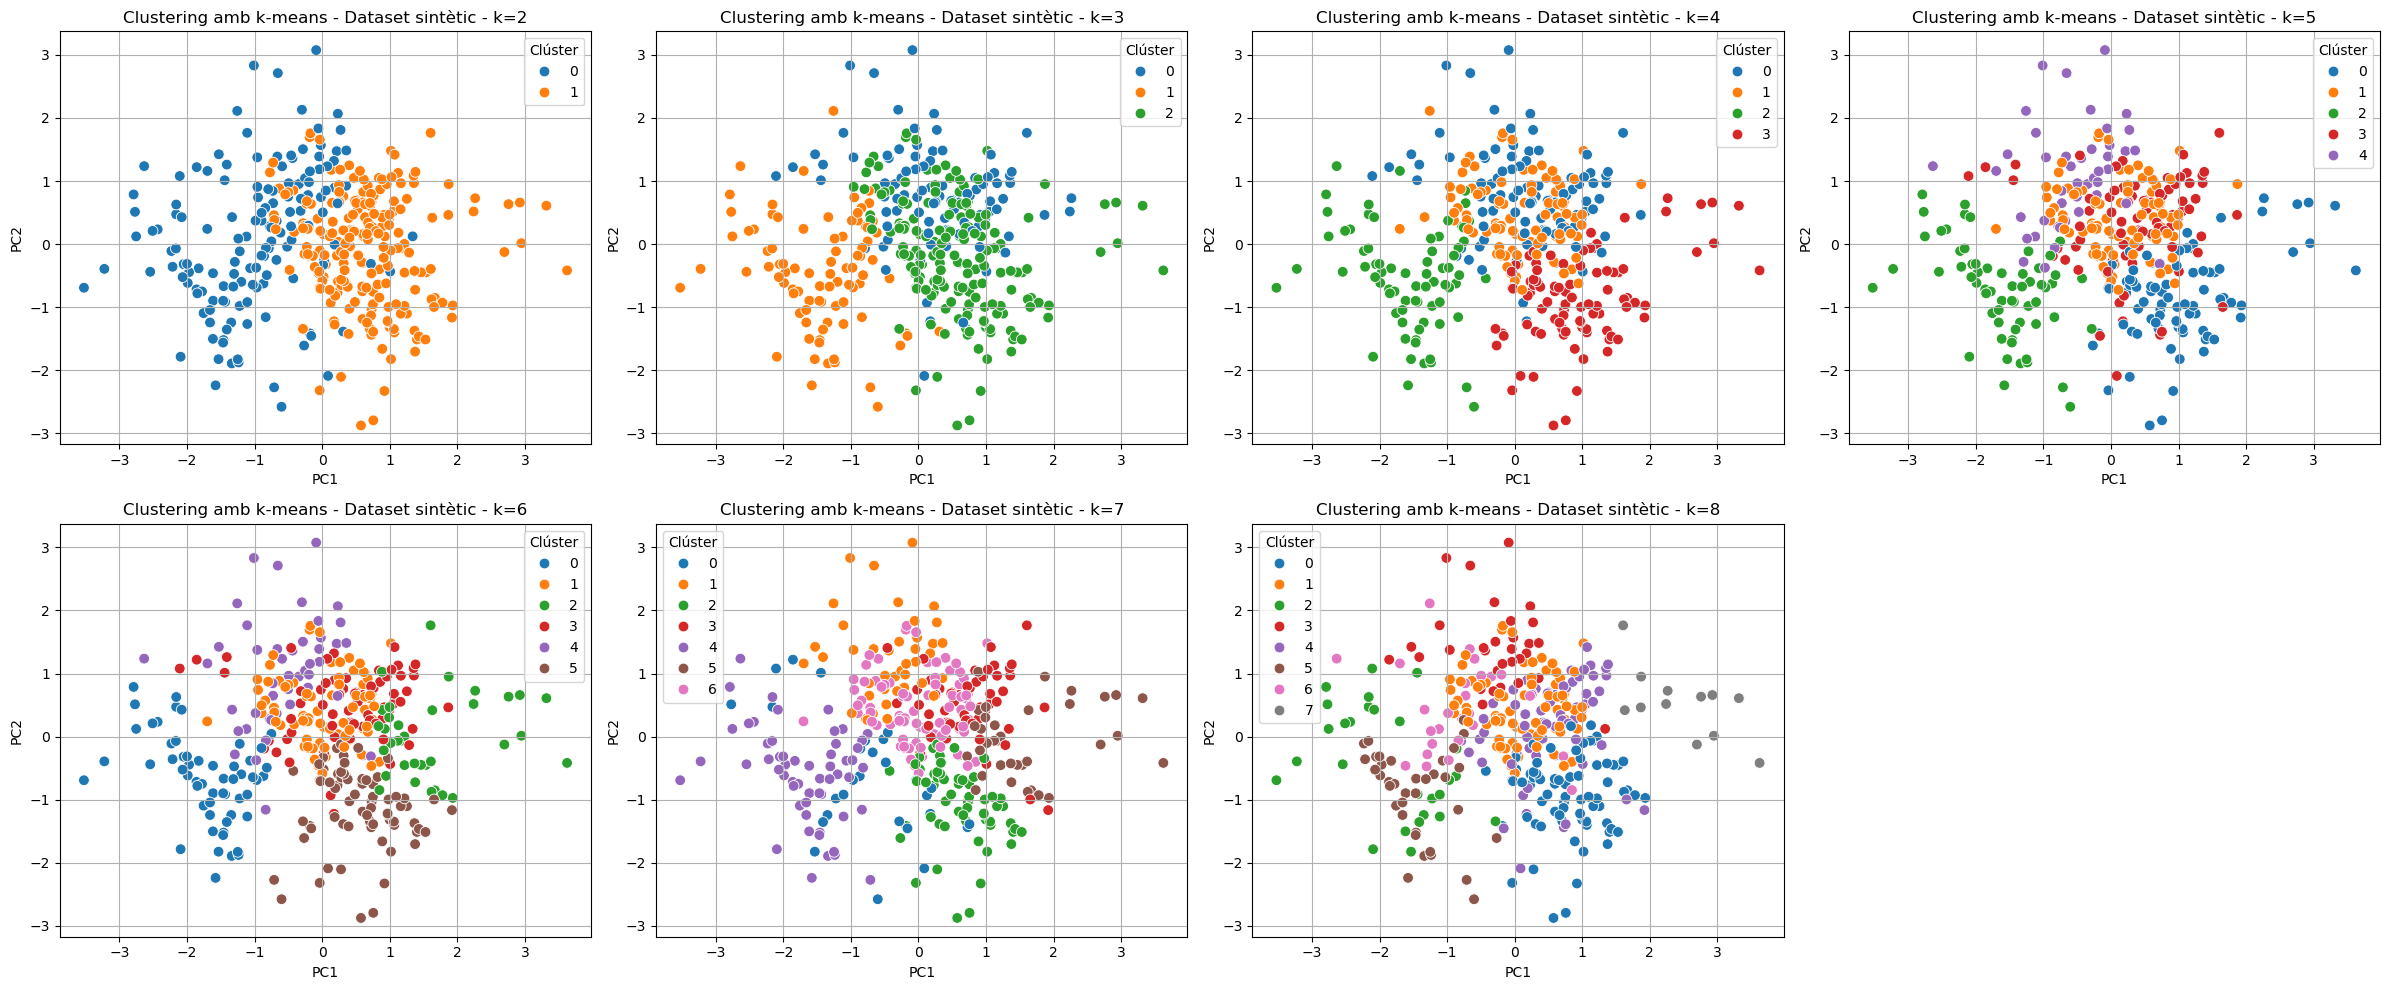

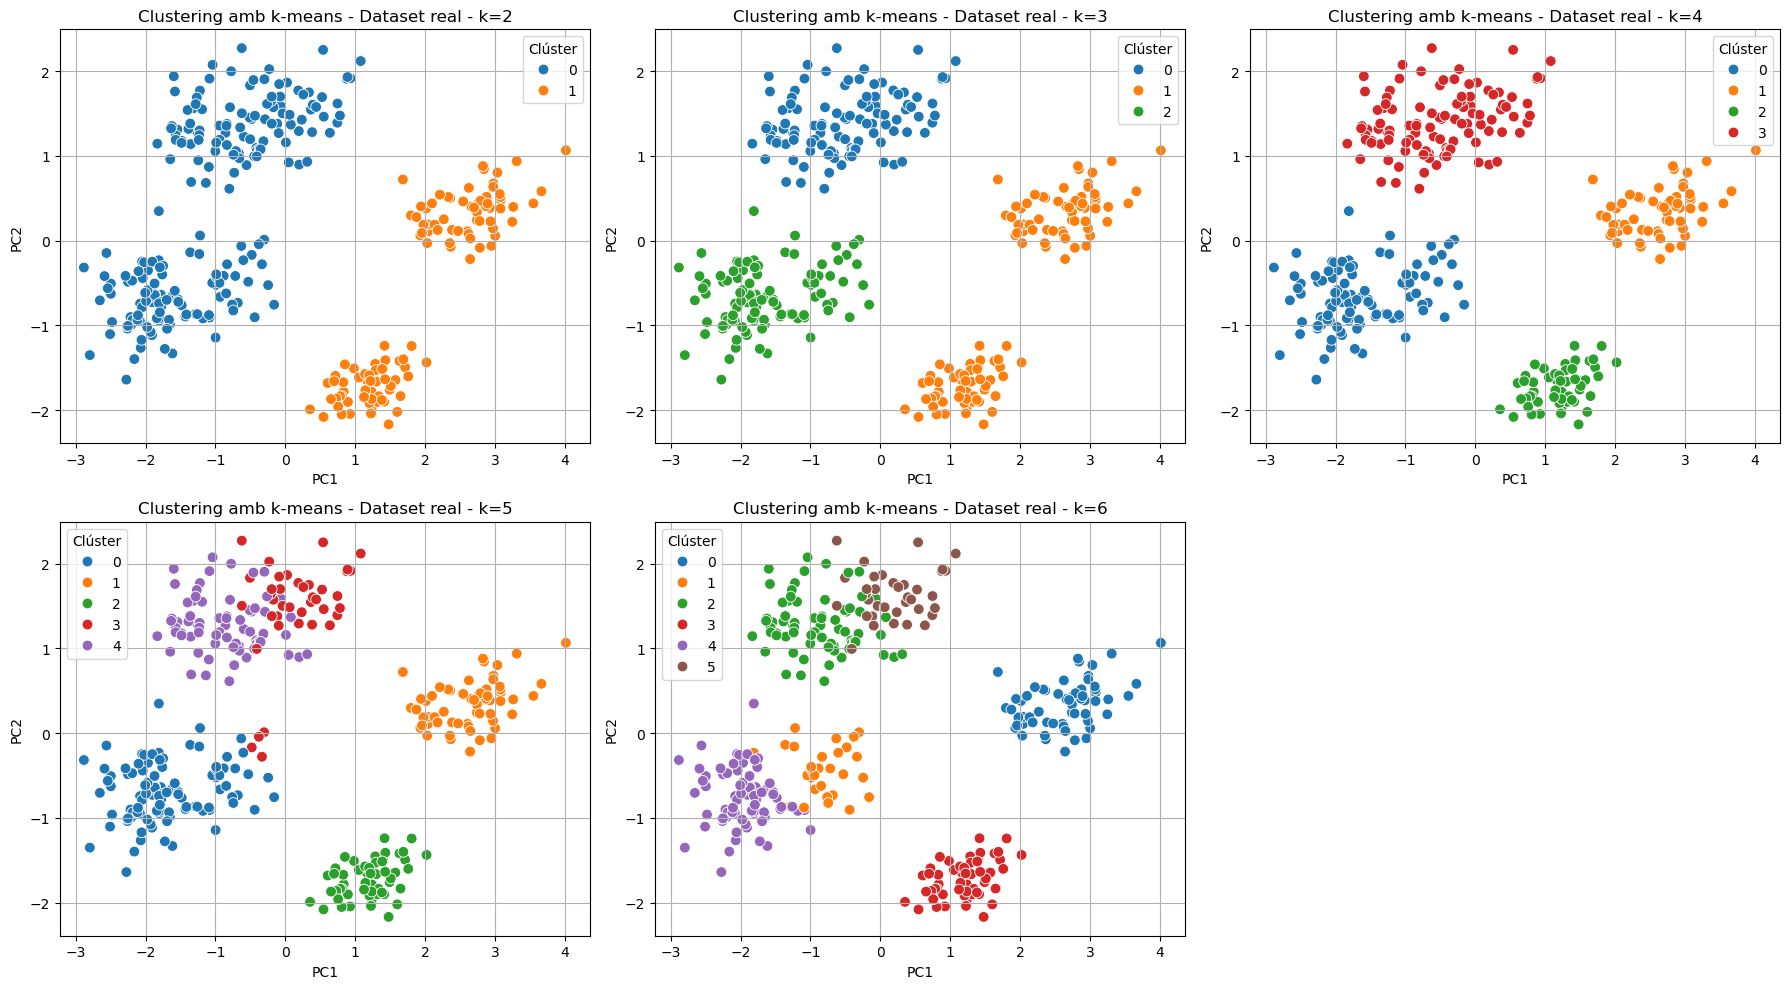

In [14]:
k_values_syn = range(2, 9)

kmeans_syn_results_df, kmeans_syn_results = apply_kmeans(
    X_syn_scaled_df,
    pca_syn_df,
    y_syn,
    "Dataset sintètic",
    k_values_syn
)


k_values_real = range(2, 7)

kmeans_real_results_df, kmeans_real_results = apply_kmeans(
    X_real_scaled_df,
    pca_real_df,
    y_real,
    "Dataset real",
    k_values_real
)

#### Conclusions k-means

En el dataset sintètic, els clústers obtinguts amb k-means no separen de manera gaire clara l'estructura de les dades. Per valors baixos de k, com k=2o k=3, l'algorisme divideix les dades en zones bastant generals, però encara hi ha molta barreja. Quan s'augmenta k, apareixen clústers més petits, però això no implica necessàriament una millor correspondència, ja que alguns grups fragmenten regions que ja estaven barrejades.

En el dataset real, la separació és molt més clara. Amb k=2, k-means ja distingeix dos grans blocs de punts, però encara agrupa classes que visualment semblen diferents. Amb k=3 i k=4, els clústers obtinguts s'ajusten millor a l'estructura principal de les dades, ja que apareixen grups força diferenciats. En canvi, per valors més alts de k, l'algorisme comença a dividir grups que ja eren compactes en subgrups més petits.

Per tant, visualment, el dataset real presenta una estructura més adequada per a k-means que el dataset sintètic. En particular, \(k=3\) sembla una bona elecció per al dataset real, mentre que en el dataset sintètic la separació és menys evident i l'augment de \(k\) no millora clarament la interpretació.

#### Comparació amb les classes reals

In [15]:
def plot_kmeans_scores(results_df, dataset_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(results_df["k"], results_df["ARI"], marker="o", label="ARI")
    ax.plot(results_df["k"], results_df["NMI"], marker="o", label="NMI")

    ax.set_title(f"Comparació k-means amb classes reals - {dataset_name}")
    ax.set_xlabel("Nombre de clústers k")
    ax.set_ylabel("Score")
    ax.set_xticks(results_df["k"])
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True)

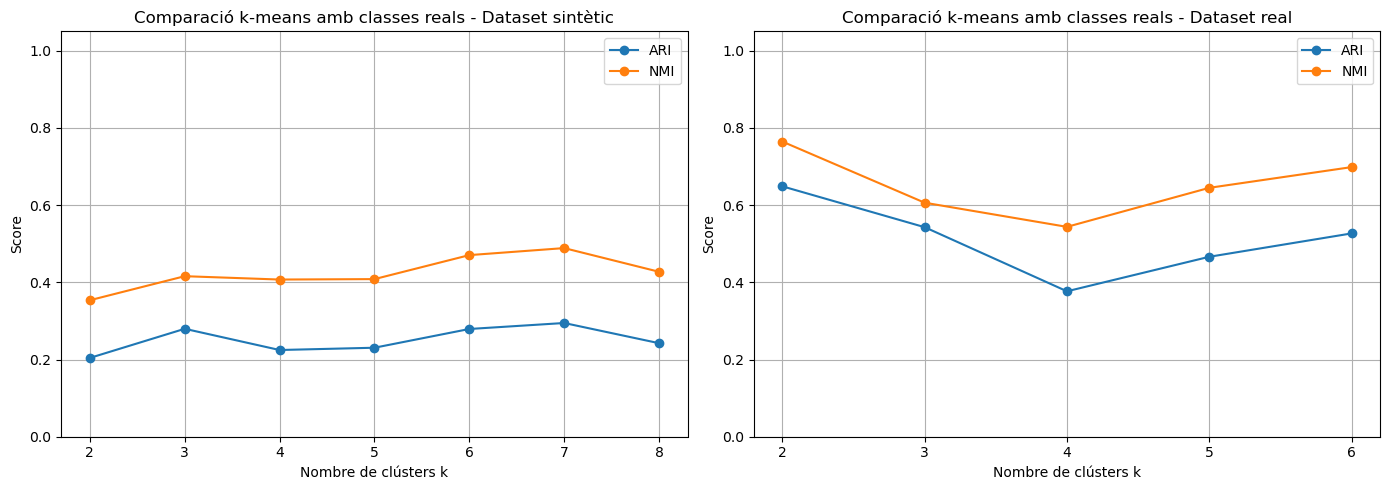

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_kmeans_scores(kmeans_syn_results_df, "Dataset sintètic", ax=axes[0])
plot_kmeans_scores(kmeans_real_results_df, "Dataset real", ax=axes[1])

plt.tight_layout()
plt.show()

S'han calculat dues mètriques per comparar els grups obtinguts amb les classes reals: l'ARI i l'NMI. Aquestes mesuren si les assignacions de k-means coincideixen amb les etiquetes reals del dataset.

En el dataset sintètic, els valors d'ARI i NMI són baixos per a tots els valors de k. Això indica que els clústers trobats per k-means no coincideixen gaire amb les classes reals. Tot i que alguns valors, com k=6 o k=7, milloren lleugerament les mètriques, la correspondència continua sent limitada. Per tant, el dataset sintètic no presenta una estructura clarament adequada per ser separada amb k-means.

En el dataset real, els valors d'ARI i NMI són més alts que en el sintètic, cosa que confirma que la seva estructura és més coherent amb els clústers trobats. Les mètriques són màximes per k=2, encara que el dataset tingui tres classes reals. Això pot passar perquè k-means detecta molt bé dos grans blocs principals de dades. Quan s'augmenta k, l'algorisme pot separar millor algunes subestructures visuals, però també pot dividir una mateixa classe real en diversos clústers, fet que redueix l'ARI i l'NMI.

Finalment, k=4 pot semblar visualment una bona opció perquè genera grups compactes i ben separats, però les mètriques indiquen que aquesta partició no coincideix tan bé amb les classes reals. 

### 4) AHC (Agglomerative Hierarchical Clustering )

Aquest mètode de clustering jeràrquic que permet estudiar l’estructura de les dades a diferents nivells d’agrupació. El mètode comença considerant cada patró com un clúster independent. A cada pas, es busquen els dos clústers més propers segons la distància euclidiana i el criteri d’enllaç escollit, i es fusionen en un únic clúster. Aquest procés es repeteix fins que tots els patrons queden agrupats dins d’una mateixa estructura jeràrquica.

S’han comparat dos criteris d’enllaç diferents: UPGMA (unweighted average linkage) i complete linkage. En el primer cas, la distància entre dos clústers es calcula a partir de la distància mitjana entre els seus punts, mentre que en el segon cas es considera la distància màxima entre punts de clústers diferents. 

In [17]:
def apply_ahc_dendrograms(X_scaled, y, dataset_name):

    # Reiniciem l'índex de les classes per poder accedir-hi correctament amb iloc
    y = pd.Series(y).reset_index(drop=True)

    # Calculem les distàncies euclidianes entre tots els parells de patrons en format comprimit
    distance_matrix = pdist(X_scaled, metric="euclidean")

    # Assigna un color a cada classe real, només per a la visualització
    classes = sorted(y.unique())
    palette = sns.color_palette("tab10", n_colors=len(classes))
    class_to_color = {cls: palette[i] for i, cls in enumerate(classes)}

    # mètodes que ens demanen
    methods = {
        "UPGMA / average linkage": "average",
        "Complete linkage": "complete"
    }

    linkage_results = {}

    for title, method in methods.items():

        # Calculem l'agrupament jeràrquic fusionant progressivament els clústers segons el criteri d'enllaç escollit
        Z = linkage(
            distance_matrix,
            method=method,
            optimal_ordering=True
        )

        linkage_results[method] = Z

        plt.figure(figsize=(18, 7))
        ax = plt.gca()

        dendro = dendrogram(
            Z,
            labels=[str(cls) for cls in y],
            leaf_rotation=90,
            leaf_font_size=6,
            color_threshold=0,
            above_threshold_color="black",
            ax=ax
        )

        # Pintem cada etiqueta de les fulles segons la seva classe real
        for tick_label, leaf_index in zip(ax.get_xmajorticklabels(), dendro["leaves"]):
            real_class = y.iloc[leaf_index]
            tick_label.set_color(class_to_color[real_class])

        # Llegenda
        legend_elements = [
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                label=f"Class {cls}",
                markerfacecolor=class_to_color[cls],
                markersize=8
            )
            for cls in classes
        ]

        ax.legend(
            handles=legend_elements,
            title="Real class",
            loc="upper right"
        )

        plt.title(f"Dendrograma AHC - {title} - {dataset_name}")
        plt.xlabel("Patrons / classe real")
        plt.ylabel("Distancia Euclidiana")
        plt.tight_layout()
        plt.show()

    return linkage_results

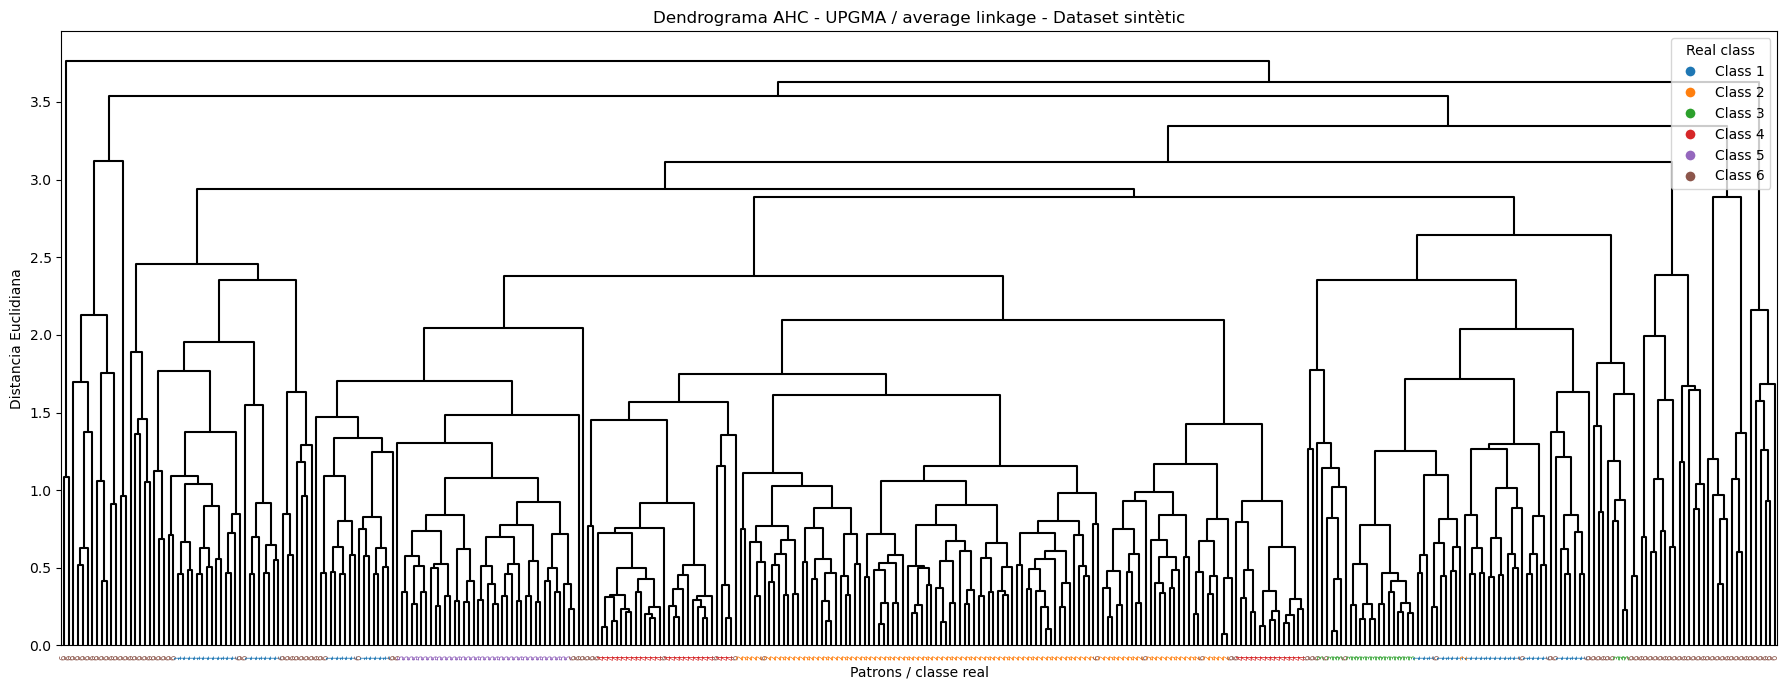

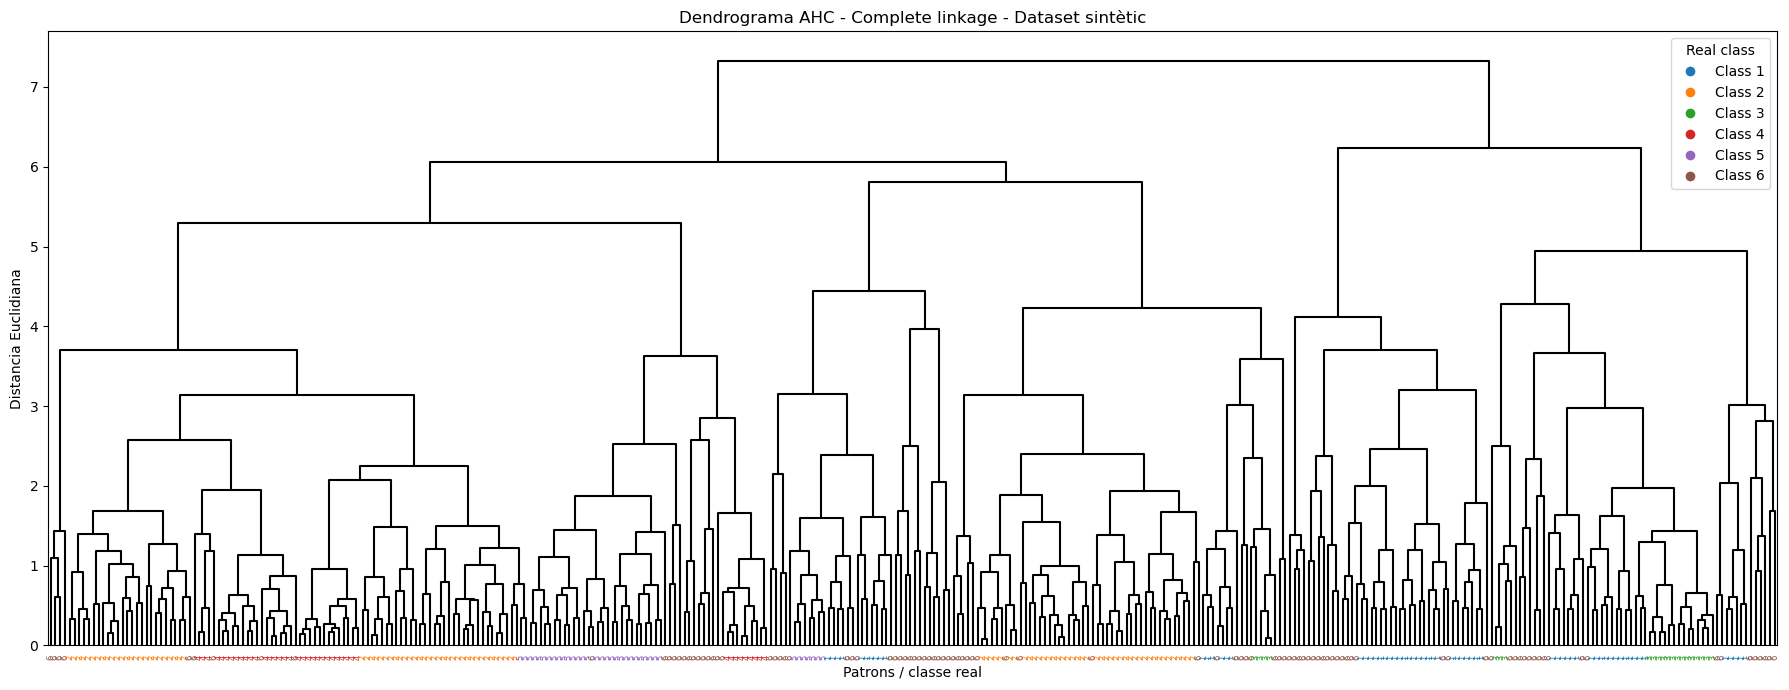

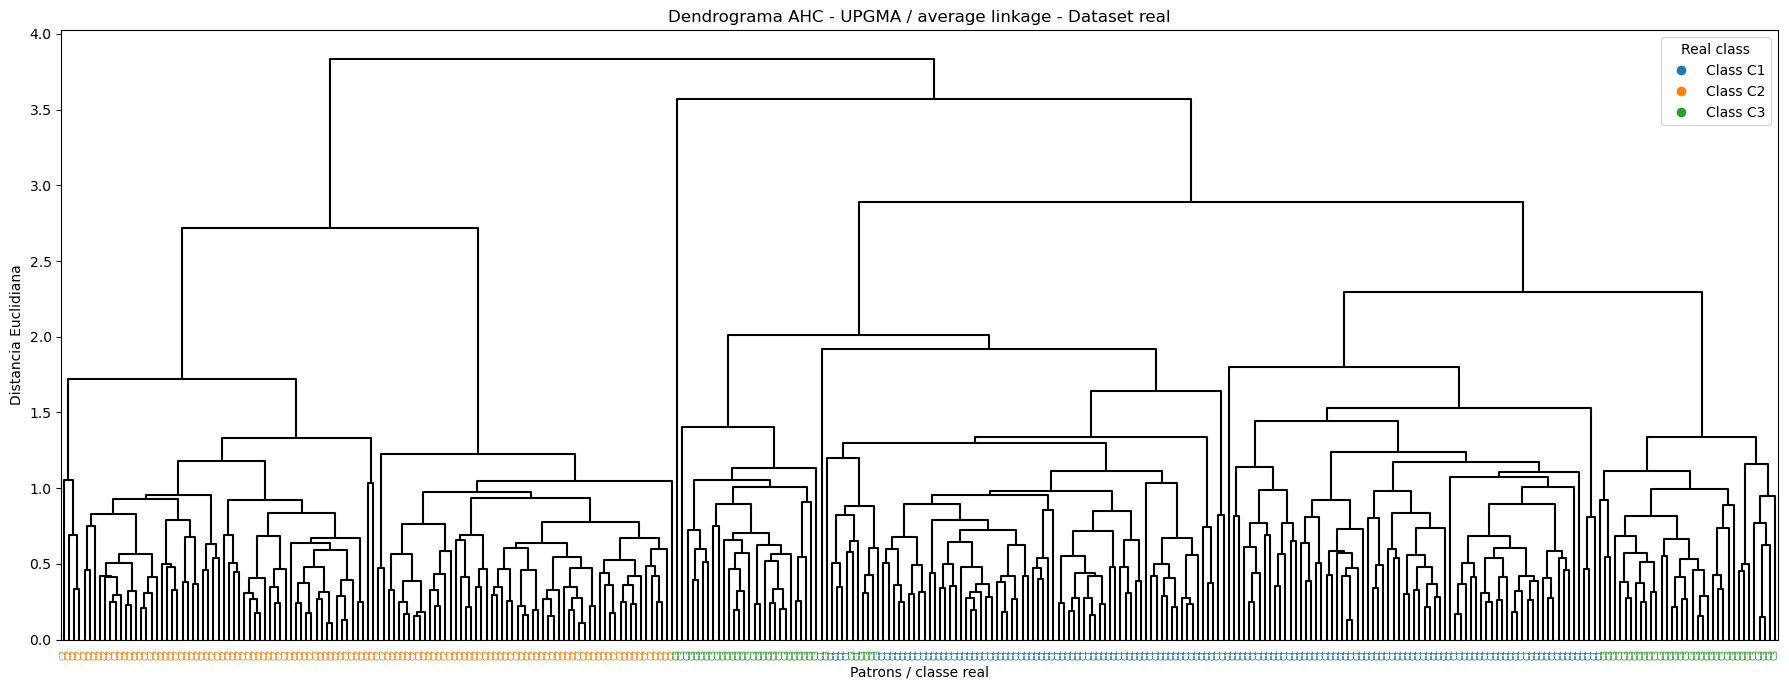

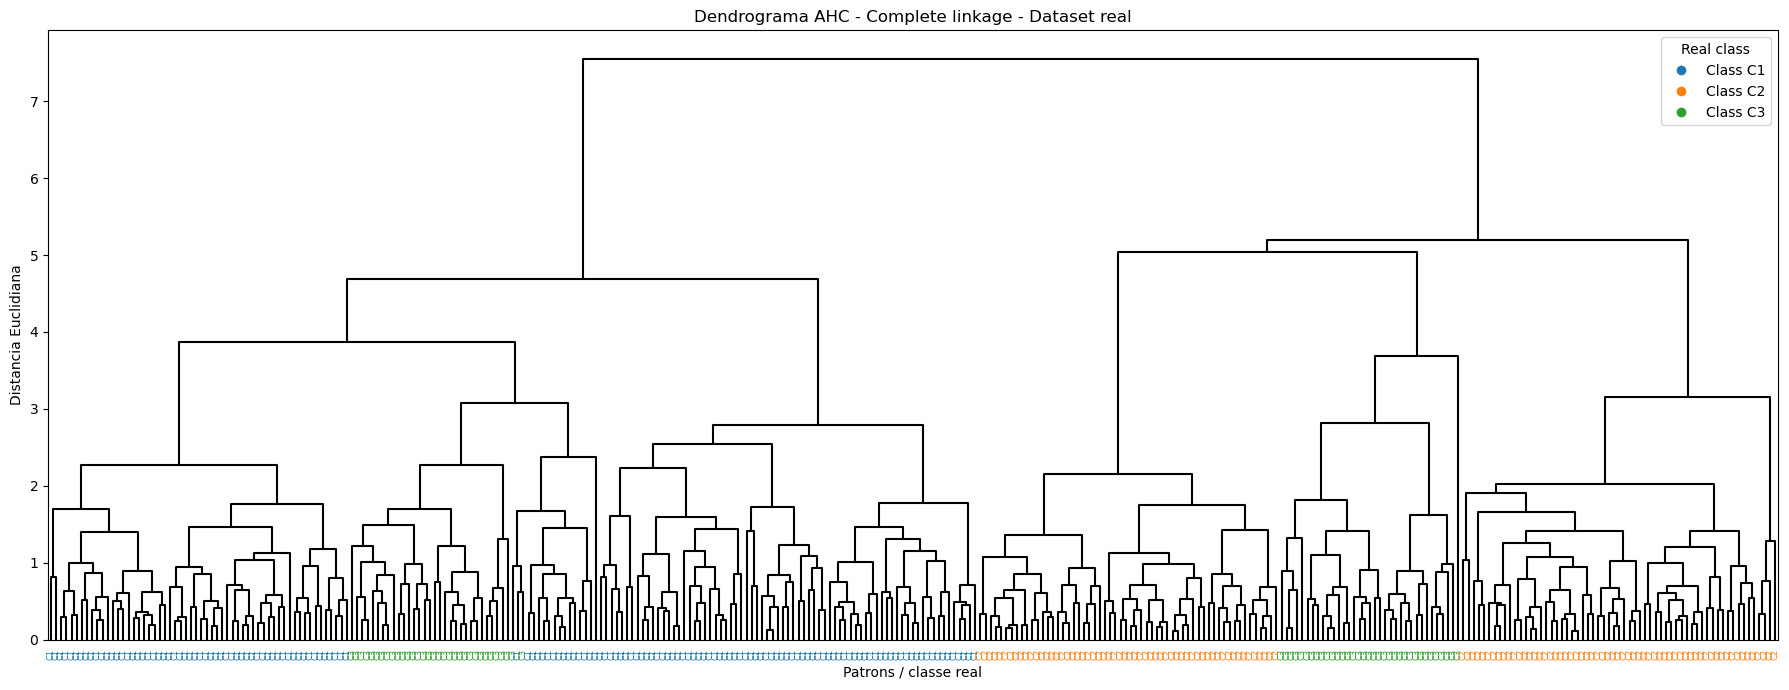

In [18]:
ahc_syn_results = apply_ahc_dendrograms(
    X_syn_scaled_df,
    y_syn,
    "Dataset sintètic"
)

ahc_real_results = apply_ahc_dendrograms(
    X_real_scaled_df,
    y_real,
    "Dataset real"
)

### Autoencoder

In [19]:
%pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [20]:
class Autoencoder2D(nn.Module):
    """
    Autoencoder with a 2-dimensional bottleneck.
    The encoder compresses the input data into 2 latent variables,
    and the decoder tries to reconstruct the original input.
    """

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

    def encode(self, x):
        return self.encoder(x)

In [21]:
def train_autoencoder_projection(
    X_scaled,
    y,
    dataset_name,
    hidden_dim=8,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3,
    random_state=42
):
    """
    Trains a PyTorch autoencoder and plots the 2D latent representation.

    Parameters
    ----------
    X_scaled : DataFrame or ndarray
        Scaled original features used as input to the autoencoder.
    y : Series or array
        Real classes. They are only used for visualization.
    dataset_name : str
        Name of the dataset.
    hidden_dim : int
        Number of neurons in the hidden layer.
    epochs : int
        Number of training epochs.
    batch_size : int
        Batch size used during training.
    learning_rate : float
        Learning rate of the Adam optimizer.
    random_state : int
        Seed for reproducibility.
    """

    torch.manual_seed(random_state)
    np.random.seed(random_state)

    X_np = np.asarray(X_scaled, dtype=np.float32)
    y = pd.Series(y).reset_index(drop=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    input_dim = X_np.shape[1]

    model = Autoencoder2D(
        input_dim=input_dim,
        hidden_dim=hidden_dim
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch in loader:
            x_batch = batch[0].to(device)

            reconstructed = model(x_batch)
            loss = criterion(reconstructed, x_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x_batch.size(0)

        epoch_loss /= len(dataset)
        losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        X_encoded = model.encode(X_tensor.to(device)).cpu().numpy()

    encoded_df = pd.DataFrame({
        "AE1": X_encoded[:, 0],
        "AE2": X_encoded[:, 1],
        "Class": y
    })

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=encoded_df,
        x="AE1",
        y="AE2",
        hue="Class",
        palette="tab10",
        s=45
    )
    plt.title(f"Autoencoder 2D projection - {dataset_name}")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.title(f"Autoencoder training loss - {dataset_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction loss (MSE)")
    plt.tight_layout()
    plt.show()

    print(f"{dataset_name}")
    print(f"Architecture: {input_dim} -> {hidden_dim} -> 2 -> {hidden_dim} -> {input_dim}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {learning_rate}")
    print(f"Final reconstruction loss: {losses[-1]:.6f}")

    return model, encoded_df, losses

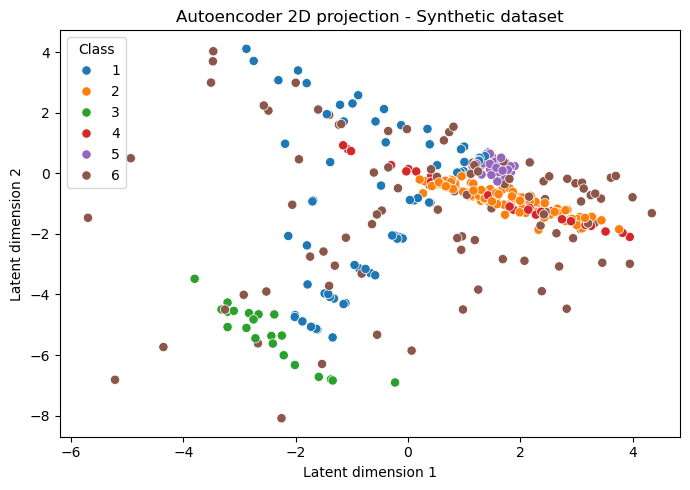

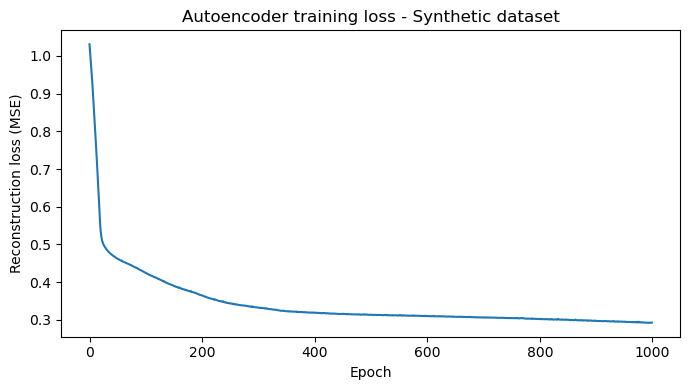

Synthetic dataset
Architecture: 4 -> 8 -> 2 -> 8 -> 4
Epochs: 1000
Batch size: 32
Learning rate: 0.001
Final reconstruction loss: 0.292816


In [22]:
ae_syn_model, ae_syn_projection, ae_syn_losses = train_autoencoder_projection(
    X_syn_scaled_df,
    y_syn,
    dataset_name="Synthetic dataset",
    hidden_dim=8,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3
)

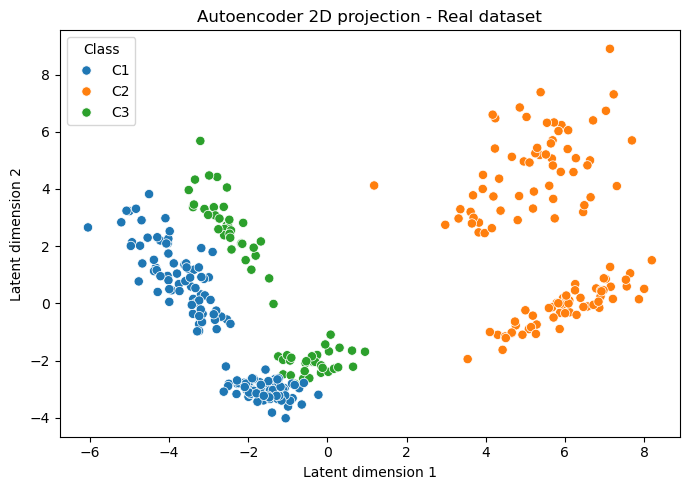

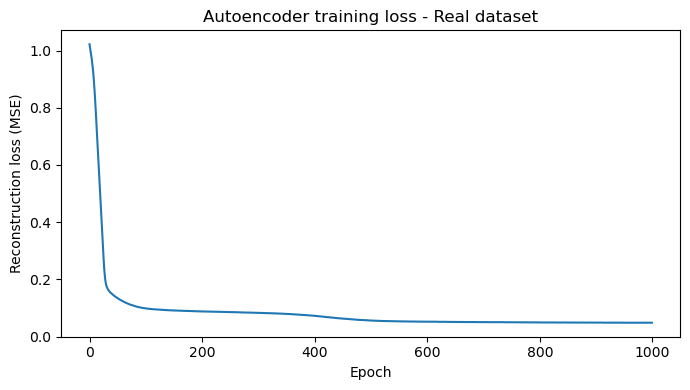

Real dataset
Architecture: 5 -> 10 -> 2 -> 10 -> 5
Epochs: 1000
Batch size: 32
Learning rate: 0.001
Final reconstruction loss: 0.048738


In [23]:
ae_real_model, ae_real_projection, ae_real_losses = train_autoencoder_projection(
    X_real_scaled_df,
    y_real,
    dataset_name="Real dataset",
    hidden_dim=10,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3
)

### SOM

In [24]:
def train_single_som(
    X_scaled,
    map_size=(10, 10),
    learning_rate=0.5,
    sigma=1.5,
    neighborhood_function="gaussian",
    topology="rectangular",
    num_iteration=3000,
    random_seed=42
):
    """
    Trains a SOM with a given set of parameters.
    """

    X = np.asarray(X_scaled, dtype=np.float64)
    input_len = X.shape[1]

    som = MiniSom(
        x=map_size[0],
        y=map_size[1],
        input_len=input_len,
        sigma=sigma,
        learning_rate=learning_rate,
        neighborhood_function=neighborhood_function,
        topology=topology,
        random_seed=random_seed
    )

    som.random_weights_init(X)
    som.train_random(X, num_iteration=num_iteration)

    quantization_error = som.quantization_error(X)

    try:
        topographic_error = som.topographic_error(X)
    except Exception:
        topographic_error = np.nan

    return som, quantization_error, topographic_error

In [25]:
def plot_som_class_map(som, X_scaled, y, title):
    """
    Plots the dominant real class assigned to each SOM neuron.
    The classes are only used for visualization, not for training.
    """

    X = np.asarray(X_scaled, dtype=np.float64)
    y = pd.Series(y).reset_index(drop=True)

    weights = som.get_weights()
    map_x, map_y = weights.shape[0], weights.shape[1]

    labels_per_neuron = [[[] for _ in range(map_y)] for _ in range(map_x)]

    for x_i, label in zip(X, y):
        winner = som.winner(x_i)
        labels_per_neuron[winner[0]][winner[1]].append(label)

    classes = sorted(y.unique(), key=lambda v: str(v))
    class_to_int = {cls: i for i, cls in enumerate(classes)}

    class_grid = np.full((map_x, map_y), np.nan)
    count_grid = np.zeros((map_x, map_y), dtype=int)

    for i in range(map_x):
        for j in range(map_y):
            if len(labels_per_neuron[i][j]) > 0:
                dominant_class = Counter(labels_per_neuron[i][j]).most_common(1)[0][0]
                class_grid[i, j] = class_to_int[dominant_class]
                count_grid[i, j] = len(labels_per_neuron[i][j])

    palette = sns.color_palette("tab10", n_colors=len(classes))
    cmap = ListedColormap(palette.as_hex())
    cmap.set_bad("lightgray")

    plt.figure(figsize=(7, 6))
    plt.imshow(
        class_grid.T,
        origin="lower",
        cmap=cmap,
        vmin=0,
        vmax=len(classes) - 1
    )

    plt.title(title)
    plt.xlabel("SOM x")
    plt.ylabel("SOM y")

    legend_elements = [
        Patch(facecolor=palette[i], label=f"Class {cls}")
        for i, cls in enumerate(classes)
    ]

    plt.legend(
        handles=legend_elements,
        title="Dominant class",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [26]:
def plot_som_u_matrix(som, title):
    """
    Plots the U-matrix of the SOM.
    High values indicate stronger separation between neighboring neurons.
    """

    u_matrix = som.distance_map()

    plt.figure(figsize=(7, 6))
    plt.imshow(u_matrix.T, origin="lower")
    plt.colorbar(label="Mean distance to neighboring neurons")
    plt.title(title)
    plt.xlabel("SOM x")
    plt.ylabel("SOM y")
    plt.tight_layout()
    plt.show()

In [27]:
def run_som_experiments(X_scaled, y, dataset_name, configs, feature_names=None):
    """
    Trains several SOMs with different parameters and plots:
    - dominant class heatmap
    - U-matrix

    Then selects the best map according to quantization error.
    """

    X = np.asarray(X_scaled, dtype=np.float64)

    if feature_names is None:
        if isinstance(X_scaled, pd.DataFrame):
            feature_names = list(X_scaled.columns)
        else:
            feature_names = [f"Feature {i+1}" for i in range(X.shape[1])]

    results = []

    for idx, config in enumerate(configs, start=1):

        print(f"\nTraining SOM {idx} - {dataset_name}")
        print(config)

        som, qe, te = train_single_som(
            X_scaled=X,
            map_size=config["map_size"],
            learning_rate=config["learning_rate"],
            sigma=config["sigma"],
            neighborhood_function=config["neighborhood_function"],
            topology=config["topology"],
            num_iteration=config["num_iteration"],
            random_seed=config["random_seed"]
        )

        results.append({
            "config_id": idx,
            "dataset": dataset_name,
            "map_size": config["map_size"],
            "n_neurons": config["map_size"][0] * config["map_size"][1],
            "learning_rate": config["learning_rate"],
            "sigma": config["sigma"],
            "neighborhood_function": config["neighborhood_function"],
            "topology": config["topology"],
            "num_iteration": config["num_iteration"],
            "quantization_error": qe,
            "topographic_error": te,
            "som": som
        })

        plot_som_class_map(
            som,
            X,
            y,
            title=f"SOM dominant class map - {dataset_name} - Config {idx}"
        )

        plot_som_u_matrix(
            som,
            title=f"SOM U-matrix - {dataset_name} - Config {idx}"
        )

        print(f"Quantization error: {qe:.4f}")
        print(f"Topographic error: {te:.4f}")

    results_df = pd.DataFrame(results).drop(columns=["som"])
    display(results_df)

    best_idx = results_df["quantization_error"].idxmin()
    best_config_id = int(results_df.loc[best_idx, "config_id"])
    best_som = results[best_config_id - 1]["som"]

    print(f"\nBest SOM for {dataset_name}: Config {best_config_id}")
    print(results_df.loc[best_idx])

    plot_component_planes(
        best_som,
        feature_names=feature_names,
        title=f"Component planes - Best SOM - {dataset_name}"
    )

    return results, results_df, best_som

In [28]:
som_configs = [
    {
        "map_size": (10, 10),
        "learning_rate": 0.5,
        "sigma": 1.5,
        "neighborhood_function": "gaussian",
        "topology": "rectangular",
        "num_iteration": 3000,
        "random_seed": 42
    },
    {
        "map_size": (12, 12),
        "learning_rate": 0.5,
        "sigma": 2.0,
        "neighborhood_function": "gaussian",
        "topology": "rectangular",
        "num_iteration": 3000,
        "random_seed": 42
    },
    {
        "map_size": (10, 10),
        "learning_rate": 0.3,
        "sigma": 1.5,
        "neighborhood_function": "mexican_hat",
        "topology": "rectangular",
        "num_iteration": 3000,
        "random_seed": 42
    },
    {
        "map_size": (12, 12),
        "learning_rate": 0.3,
        "sigma": 2.0,
        "neighborhood_function": "gaussian",
        "topology": "hexagonal",
        "num_iteration": 3000,
        "random_seed": 42
    }
]


Training SOM 1 - Synthetic dataset
{'map_size': (10, 10), 'learning_rate': 0.5, 'sigma': 1.5, 'neighborhood_function': 'gaussian', 'topology': 'rectangular', 'num_iteration': 3000, 'random_seed': 42}


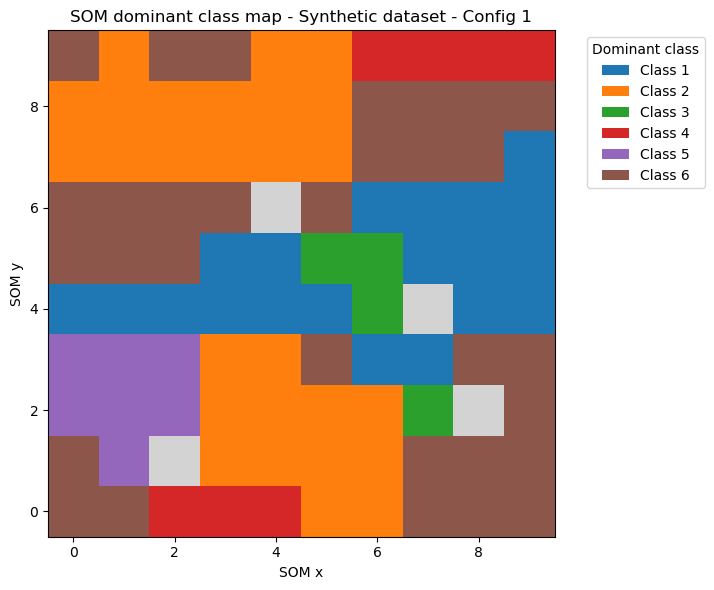

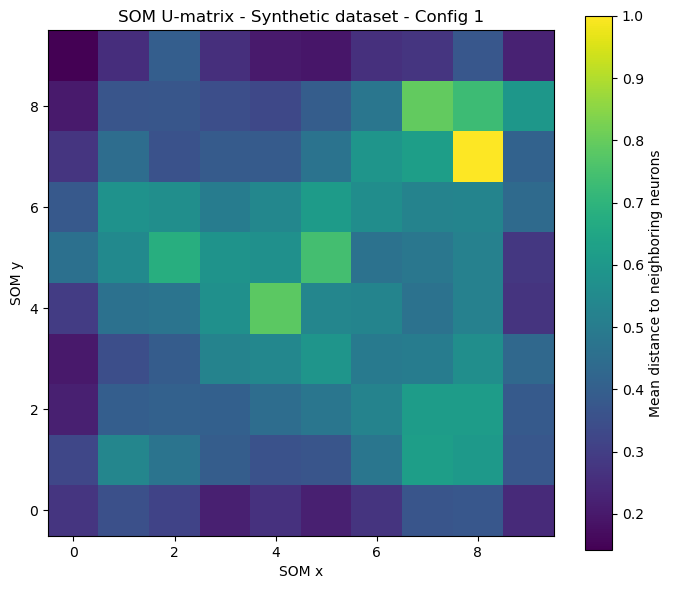

Quantization error: 0.5129
Topographic error: 0.1167

Training SOM 2 - Synthetic dataset
{'map_size': (12, 12), 'learning_rate': 0.5, 'sigma': 2.0, 'neighborhood_function': 'gaussian', 'topology': 'rectangular', 'num_iteration': 3000, 'random_seed': 42}


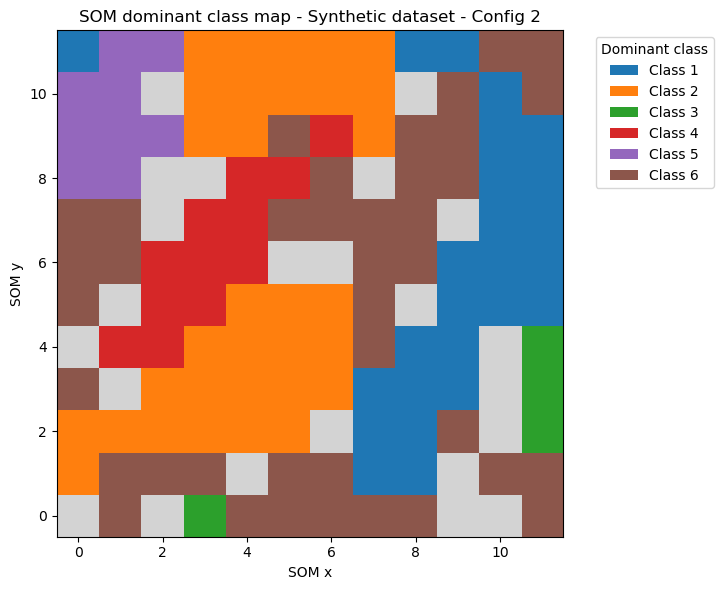

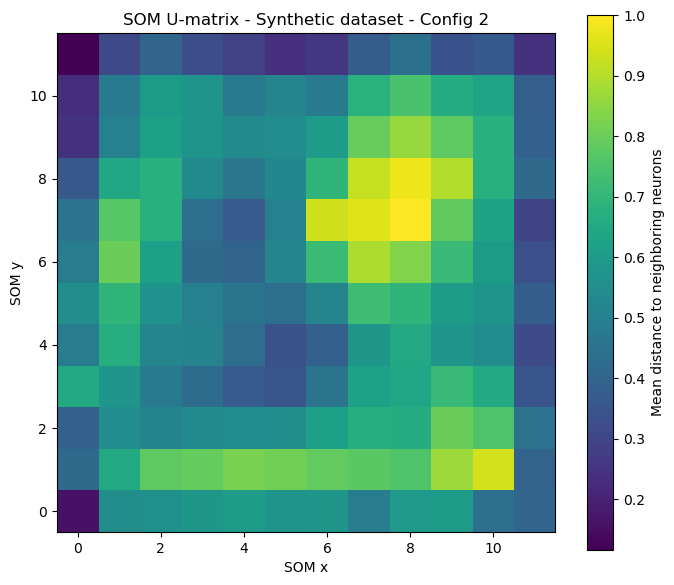

Quantization error: 0.4972
Topographic error: 0.0639

Training SOM 3 - Synthetic dataset
{'map_size': (10, 10), 'learning_rate': 0.3, 'sigma': 1.5, 'neighborhood_function': 'mexican_hat', 'topology': 'rectangular', 'num_iteration': 3000, 'random_seed': 42}


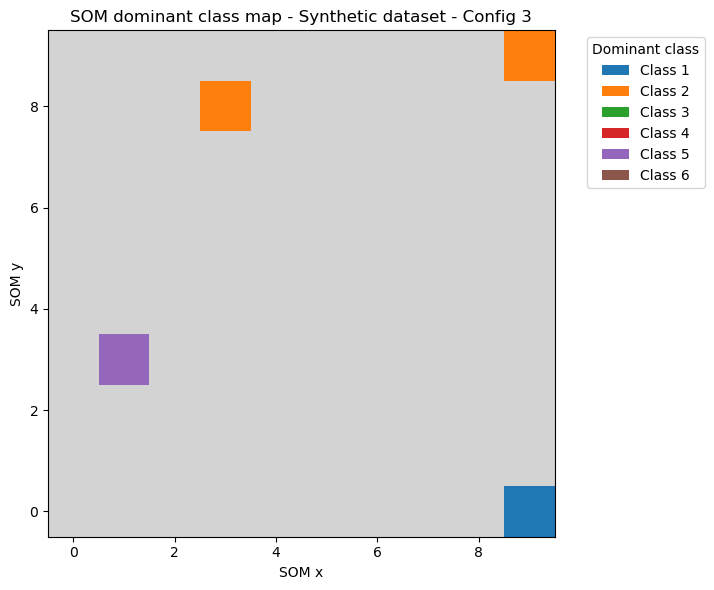

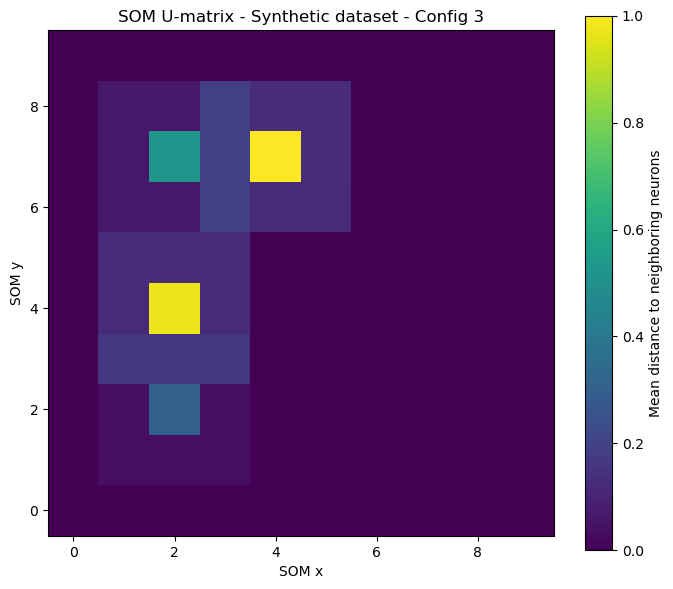

Quantization error: 1.3702
Topographic error: 1.0000

Training SOM 4 - Synthetic dataset
{'map_size': (12, 12), 'learning_rate': 0.3, 'sigma': 2.0, 'neighborhood_function': 'gaussian', 'topology': 'hexagonal', 'num_iteration': 3000, 'random_seed': 42}


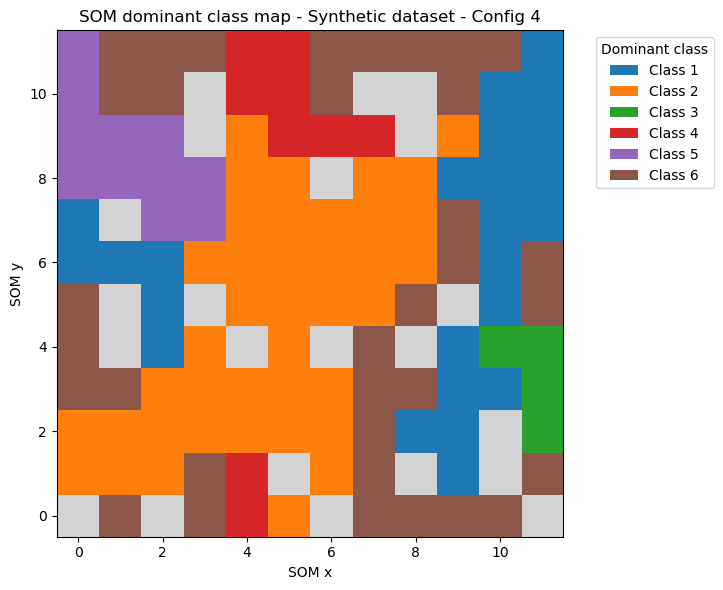

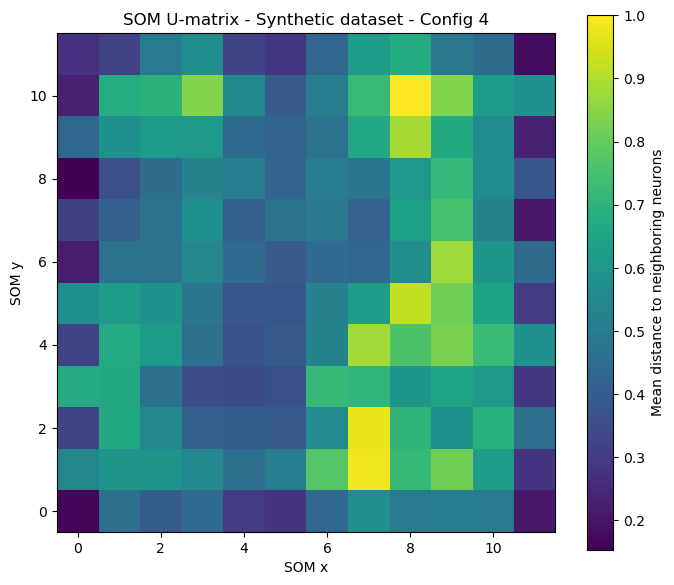

Quantization error: 0.5443
Topographic error: 0.0778


,config_id,dataset,map_size,n_neurons,learning_rate,sigma,neighborhood_function,topology,num_iteration,quantization_error,topographic_error
0,1,Synthetic dataset,"(10, 10)",100,0.5,1.5,gaussian,rectangular,3000,0.512924,0.116667
1,2,Synthetic dataset,"(12, 12)",144,0.5,2.0,gaussian,rectangular,3000,0.497152,0.063889
2,3,Synthetic dataset,"(10, 10)",100,0.3,1.5,mexican_hat,rectangular,3000,1.370181,1.000000
3,4,Synthetic dataset,"(12, 12)",144,0.3,2.0,gaussian,hexagonal,3000,0.544301,0.077778



Best SOM for Synthetic dataset: Config 2
config_id                                2
dataset                  Synthetic dataset
map_size                          (12, 12)
n_neurons                              144
learning_rate                          0.5
sigma                                  2.0
neighborhood_function             gaussian
topology                       rectangular
num_iteration                         3000
quantization_error                0.497152
topographic_error                 0.063889
Name: 1, dtype: object


NameError: name 'plot_component_planes' is not defined

In [29]:
som_syn_results, som_syn_results_df, best_som_syn = run_som_experiments(
    X_scaled=X_syn_scaled_df,
    y=y_syn,
    dataset_name="Synthetic dataset",
    configs=som_configs
)

In [ ]:
som_real_results, som_real_results_df, best_som_real = run_som_experiments(
    X_scaled=X_real_scaled_df,
    y=y_real,
    dataset_name="Real dataset",
    configs=som_configs
)